In [1]:
# Provides support for numerical computations and multi-dimensional arrays.
import numpy as np  

# Offers powerful data manipulation and analysis tools using DataFrames.
import pandas as pd  


# Enables creation of static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt  

# Allows custom colormap creation for matplotlib plots.
from matplotlib.colors import LinearSegmentedColormap  

# Simplifies statistical data visualization and integrates seamlessly with matplotlib.
import seaborn as sns  


# Facilitates creation of interactive visualizations and dashboards using Plotly.
import plotly.graph_objects as go  

# Offers high-level interface for creating interactive Plotly visualizations quickly.
import plotly.express as px  

# Provides tools for arranging multiple subplots in Plotly visualizations.
import plotly.subplots as sp  

# Simplifies the creation of complex subplot layouts.
from plotly.subplots import make_subplots  

# Enables detailed control of individual Plotly plot objects.
import plotly.graph_objs as go  


# Tools for encoding categorical variables.
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer  

# Provides scaling tools for normalizing features.
from sklearn.preprocessing import MinMaxScaler, StandardScaler  

# Function to compute mean absolute error for model evaluation.
from sklearn.metrics import mean_absolute_error  

# Performs Principal Component Analysis for dimensionality reduction.
from sklearn.decomposition import PCA  


# Offers utilities for generating random numbers and sequences.
import random  

# Provides functions for calculating statistical measures (mean, median, etc.).
import statistics

### Loading datasets

The code snippet loads `data_train` and `data_test` from: 


In [2]:
train_path = "data/output/00_data_understanding/data_test.csv"
test_path = "data/output/00_data_understanding/data_train.csv"

In [3]:
data_train = pd.read_csv(train_path)
data_test = pd.read_csv(test_path)

print("Datasets loaded successfully.")        # Prints a message if the datasets are loaded successfully.

Datasets loaded successfully.


# Plots

## World map `contryOfOrigins`

In [4]:
import pandas as pd
import plotly.express as px
from iso3166 import countries_by_alpha2  # Install via: pip install iso3166
import numpy as np

def load_iso_country_codes(file_path):
    """
    Carica i codici paese ISO-2 da un file .txt.

    Parametri:
    - file_path (str): Percorso al file .txt contenente i codici ISO.

    Ritorna:
    - set: Un set di codici paese ISO-2.
    """
    with open(file_path, 'r') as file:
        country_codes = {line.strip() for line in file if line.strip()}
    return country_codes

def convert_iso2_to_iso3(iso2_codes):
    """
    Converte i codici paese ISO-2 in ISO-3.

    Parametri:
    - iso2_codes (list): Una lista di codici paese ISO-2.

    Ritorna:
    - dict: Dizionario che mappa ISO-2 a ISO-3.
    """
    iso2_to_iso3 = {}
    for iso2 in iso2_codes:
        try:
            iso2_to_iso3[iso2] = countries_by_alpha2[iso2].alpha3
        except KeyError:
            iso2_to_iso3[iso2] = None  # Paesi non mappati
    return iso2_to_iso3

def create_world_map_from_dataset(dataset, iso_country_codes):
    """
    Genera una mappa mondiale che visualizza il numero di film per paese con scala logaritmica per i colori,
    ma mostra i valori originali nei tooltip e nella barra colori.

    Parametri:
    - dataset (pd.DataFrame): Dataset con colonne one-hot dei paesi.
    - iso_country_codes (set): Set di codici paese ISO-2 validi.

    Ritorna:
    - fig: Mappa coropletica di Plotly.
    - unrepresented_countries: DataFrame con paesi non rappresentati.
    """
    # Filtra le colonne relative ai paesi
    country_columns = [col for col in dataset.columns if col in iso_country_codes]

    # Somma i conteggi dei film per ogni paese
    country_counts = dataset[country_columns].sum().reset_index()
    country_counts.columns = ['Country', 'FilmCount']

    # Converte ISO-2 in ISO-3
    iso2_to_iso3 = convert_iso2_to_iso3(country_counts['Country'])
    country_counts['ISO3'] = country_counts['Country'].map(iso2_to_iso3)

    # Identifica i paesi non rappresentati
    unrepresented_countries = country_counts[country_counts['ISO3'].isna()]
    print("Paesi non rappresentati e righe corrispondenti:")
    print(unrepresented_countries[['Country', 'FilmCount']])

    # Filtra i paesi rappresentati
    country_counts = country_counts[country_counts['ISO3'].notna()]

    # Applica la scala logaritmica per i colori
    country_counts['LogFilmCount'] = np.log1p(country_counts['FilmCount'])  # log(1 + x)

    # Crea la mappa
    fig = px.choropleth(
        country_counts,
        locations="ISO3",  # Codici paese ISO-3
        locationmode="ISO-3",  # Modalità ISO-3
        color="LogFilmCount",  # Valori logaritmici per mappare i colori
        title="Numero di film per paese",
        color_continuous_scale="Blues",
        hover_data={"LogFilmCount": False, "FilmCount": True}  # Mostra i valori originali nei tooltip
    )

    # Modifica i tick nella barra colori per mostrare i valori originali
    fig.update_coloraxes(
        colorbar_tickvals=[np.log1p(x) for x in [1, 10, 100, 1000, 10000]],
        colorbar_ticktext=["1", "10", "100", "1k", "10k"]  # Etichette leggibili
    )

    # Layout aggiornato per migliore visualizzazione
    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='equirectangular'
        )
    )

    return fig, unrepresented_countries[['Country', 'FilmCount']]

In [5]:

# Carica i codici paese ISO
iso_country_codes = load_iso_country_codes('encoding_lists/countryOfOrigin.txt')

In [6]:

# Esempio d'uso con il dataset
fig_train, unrepresented_train = create_world_map_from_dataset(data_train, iso_country_codes)

# Mostra la mappa
fig_train.show()

Paesi non rappresentati e righe corrispondenti:
    Country  FilmCount
24     CSHH         20
25     CSXX          1
29     DDDE          9
97     SUHH         98
109     XKV          1
110     XWG         93
111     XYU         16
112    YUCS          2


In [7]:

# Esempio d'uso con il dataset
fig_test, unrepresented_train = create_world_map_from_dataset(data_test, iso_country_codes)

# Mostra la mappa
fig_test.show()

Paesi non rappresentati e righe corrispondenti:
    Country  FilmCount
28     CSHH         68
29     CSXX          3
33     DDDE         29
128    SUHH        232
146     XKV          1
147     XWG        230
148     XYU         52
149    YUCS          4


# Managing not recognized values

in `countryOfOrigin.txt` there are countries that are not recognized by ISO standard used for the function. In order to manage that we looked for these values and find which country and ISO code correspondent.

unrecognized_country_mapping = {
    'CSHH': 'Czechoslovakia',
    'CSXX': 'Serbia and Montenegro',
    'DDDE': 'East Germany',
    'SUHH': 'Soviet Union',
    'XKV': 'Kosovo',
    'XWG': 'West Germany',
    'XYU': 'Yugoslavia',
    'YUCS': 'Serbia and Montenegro'
}
These are country that doesn't exists when are analyzed in the dataset, so we decided to not care about it, but just show them.

/tmp/ipykernel_6345/2087070548.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




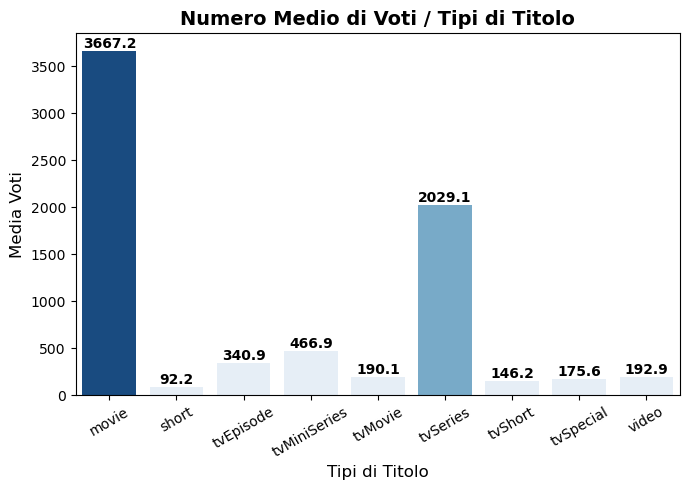

/tmp/ipykernel_6345/2087070548.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




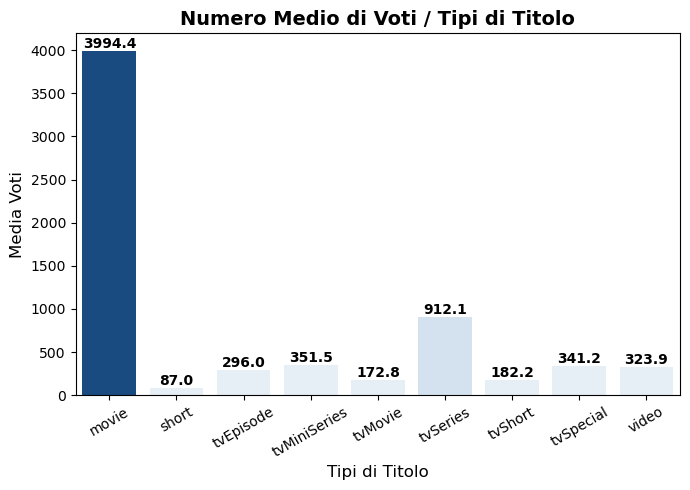

In [8]:

def generate_mean_votes_chart(data):
    if 'titleType' in data.columns and 'numVotes' in data.columns:
        votes_mean = data.groupby('titleType')['numVotes'].mean()
        
        # Normalizziamo i valori per assegnare il colore
        normalized_values = (votes_mean - votes_mean.min()) / (votes_mean.max() - votes_mean.min())
        
        # Creiamo la scala di colori usando la colormap 'Oranges'
        palette = sns.color_palette("Blues", len(votes_mean))
        color_map = [palette[int(norm * (len(palette) - 1))] for norm in normalized_values]
        
        # Impostiamo la dimensione del grafico
        plt.figure(figsize=(7, 5))
        
        # Creiamo il barplot con la scala di arancioni
        ax = sns.barplot(x=votes_mean.index, y=votes_mean.values, palette=color_map)
        
        # Aggiungiamo le etichette alle barre
        for i, value in enumerate(votes_mean.values):
            ax.text(i, value, f"{value:.1f}", ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')
        
        # Personalizziamo il grafico
        plt.xticks(rotation=30)
        plt.title('Numero Medio di Voti / Tipi di Titolo', fontsize=14, fontweight='bold')
        plt.ylabel('Media Voti', fontsize=12)
        plt.xlabel('Tipi di Titolo', fontsize=12)
        
        # Mostriamo il grafico
        plt.tight_layout()
        plt.show()
        
generate_mean_votes_chart(data_test)
generate_mean_votes_chart(data_train)

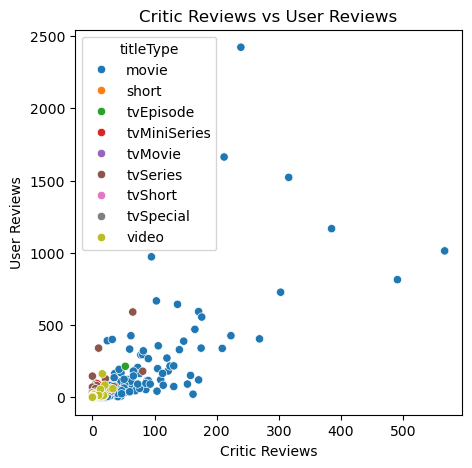

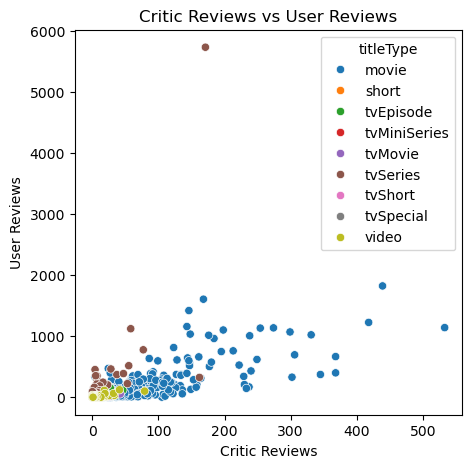

In [9]:

def generate_scatter_chart(data, x_col, y_col, hue_col='titleType', title=None, xlabel=None, ylabel=None, sort=False, color_map=None):
    if x_col in data.columns and y_col in data.columns:
        if sort and hue_col in data.columns:
            if data[hue_col].dtype.kind in 'biufc':  # Numeric types
                data = data.sort_values(by=hue_col, ascending=True)
            elif data[hue_col].dtype.kind == 'O':  # Object types (e.g., strings)
                data = data.sort_values(by=hue_col, key=lambda col: col.str.lower())

        # Define or use the color map
        if color_map is None:
            unique_hues = data[hue_col].unique()
            palette = sns.color_palette("tab10", len(unique_hues))
            color_map = dict(zip(unique_hues, palette))

        plt.figure(figsize=(5, 5))
        sns.scatterplot(x=x_col, y=y_col, data=data, hue=hue_col, palette=color_map)
        plt.title(title if title else f'{x_col} vs {y_col}')
        plt.xlabel(xlabel if xlabel else x_col)
        plt.ylabel(ylabel if ylabel else y_col)
        if hue_col in data.columns:
            plt.legend(title=hue_col)
        plt.show()
    else:
        raise ValueError(f"Columns {x_col} and/or {y_col} not found in the dataset.")


generate_scatter_chart(data_train, 'criticReviewsTotal', 'userReviewsTotal', 'titleType', 'Critic Reviews vs User Reviews', 'Critic Reviews', 'User Reviews', sort = True)
generate_scatter_chart(data_test, 'criticReviewsTotal', 'userReviewsTotal', 'titleType', 'Critic Reviews vs User Reviews', 'Critic Reviews', 'User Reviews', sort = True)

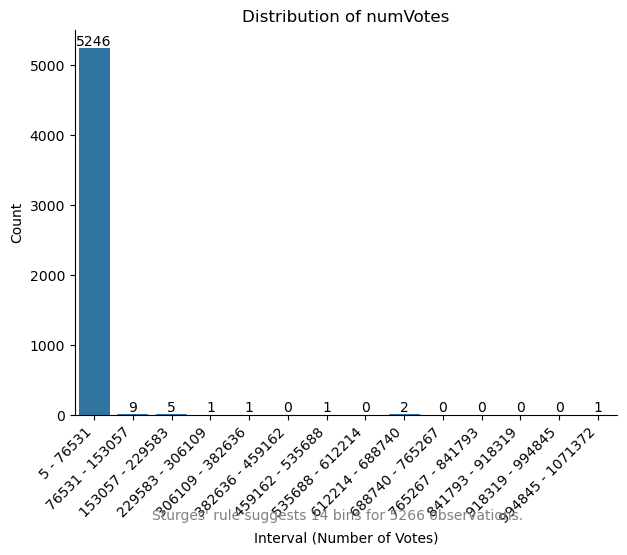

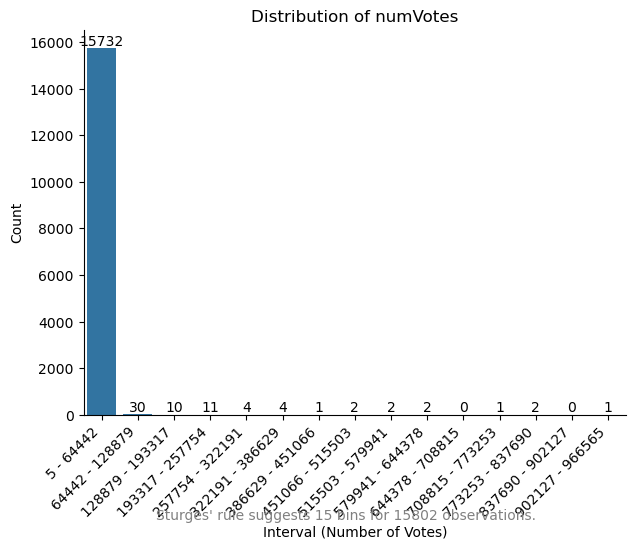

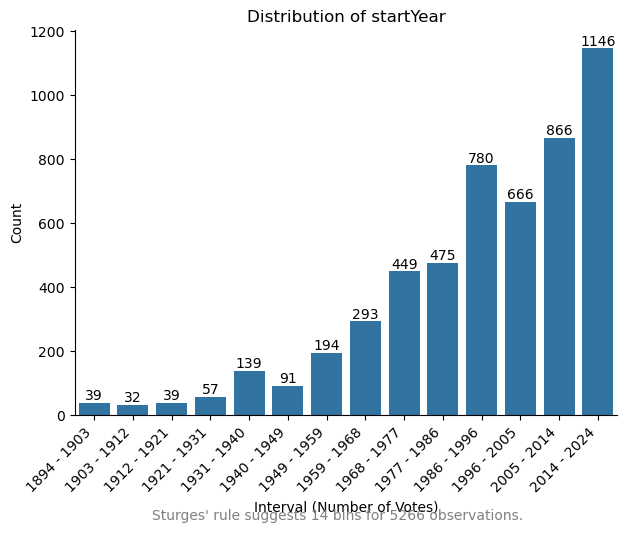

,Interval,film_count
0,1894 - 1903,39
1,1903 - 1912,32
2,1912 - 1921,39
3,1921 - 1931,57
4,1931 - 1940,139
5,1940 - 1949,91
6,1949 - 1959,194
7,1959 - 1968,293
8,1968 - 1977,449
9,1977 - 1986,475


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def generate_distribution_chart(data, column, title=None, xlabel=None, ylabel=None, use_sturges=False):
    """
    Generates a bar plot showing the distribution of a specified column and returns the distribution data.

    Parameters:
        data (pd.DataFrame): The dataset containing the columns.
        column (str): The column for which the distribution is calculated.
        title (str, optional): Title of the chart. Default is None.
        xlabel (str, optional): Label for the x-axis. Default is None.
        ylabel (str, optional): Label for the y-axis. Default is None.
        use_sturges (bool, optional): If True, uses Sturges' rule to determine the number of bins for the distribution.

    Returns:
        pd.DataFrame: A DataFrame containing the intervals and the count of rows in each interval.
    """
    if column in data.columns:
        # Calculate distribution
        if use_sturges:
            num_bins = int(np.ceil(1 + np.log2(len(data[column].dropna()))))  # Sturges' rule
            min_value = data[column].min()
            max_value = data[column].max()
            bins = np.linspace(min_value, max_value, num_bins + 1)
            bin_labels = [f"{int(bins[i])} - {int(bins[i + 1])}" for i in range(len(bins) - 1)]
            data['binned'] = pd.cut(data[column], bins=bins, include_lowest=True, labels=bin_labels)
            distribution = data['binned'].value_counts(sort=False).reset_index()
            distribution.columns = ['Interval', 'film_count']
            description = f"Sturges' rule suggests {num_bins} bins for {len(data[column].dropna())} observations."
        else:
            distribution = data[column].value_counts().reset_index()
            distribution.columns = [column, 'film_count']
            distribution = distribution.sort_values(by=column)
            description = None

        # Plotting
        plt.figure(figsize=(7, 5))
        ax = sns.barplot(x='Interval' if use_sturges else column, y='film_count', data=distribution)
        plt.title(title if title else f'Distribution of {column}')
        plt.xlabel(xlabel if xlabel else (column if not use_sturges else 'Interval (Number of Votes)'))
        plt.ylabel(ylabel if ylabel else 'Count')
        
        # Rotate x-axis labels diagonally if using Sturges' rule
        if use_sturges:
            plt.xticks(rotation=45, ha='right')
        
        # Add value labels on each bar
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, color='black')
        
        # Remove top and right borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Add description for Sturges' rule if applicable
        if description:
            plt.figtext(0.5, -0.1, description, wrap=True, horizontalalignment='center', fontsize=10, color='gray')

        plt.show()

        # Drop temporary 'binned' column if it was created
        if 'binned' in data.columns:
            data.drop(columns=['binned'], inplace=True)

        return distribution
    else:
        raise ValueError(f"Column {column} not found in the dataset.")

generate_distribution_chart(data_train, 'numVotes', use_sturges = True)
generate_distribution_chart(data_test, 'numVotes', use_sturges = True)

generate_distribution_chart(data_train, 'startYear', use_sturges = True)

/tmp/ipykernel_6345/630372876.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




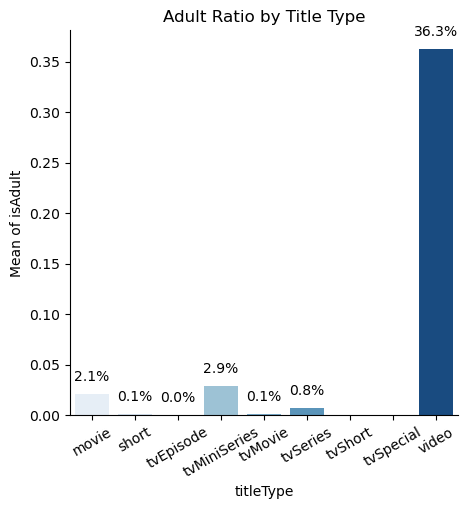

/tmp/ipykernel_6345/630372876.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




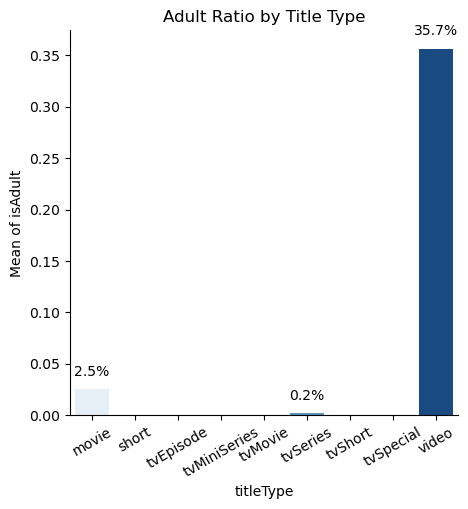

In [11]:

def generate_ratio_chart(data, group_col, value_col, title=None, xlabel=None, ylabel=None, palette="Blues"):
    if group_col in data.columns and value_col in data.columns:
        ratio = data.groupby(group_col)[value_col].mean()
        plt.figure(figsize=(5, 5))
        ax = sns.barplot(x=ratio.index, y=ratio.values, palette=sns.color_palette(palette, len(ratio)))
        
        # Add percentage labels to each bar (exclude 0.0%)
        for i, value in enumerate(ratio.values):
            if value > 0:
                ax.text(i, value + 0.01, f'{value:.1%}', ha='center', va='bottom', fontsize=10)
        
        # Remove top and right borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.xticks(rotation=30)
        plt.title(title if title else f'Mean of {value_col} by {group_col}')
        plt.xlabel(xlabel if xlabel else group_col)
        plt.ylabel(ylabel if ylabel else f'Mean of {value_col}')
        plt.show()
    else:
        raise ValueError(f"Columns {group_col} and/or {value_col} not found in the dataset.")


generate_ratio_chart(data_test, 'titleType', 'isAdult', 'Adult Ratio by Title Type')
generate_ratio_chart(data_train, 'titleType', 'isAdult', 'Adult Ratio by Title Type')

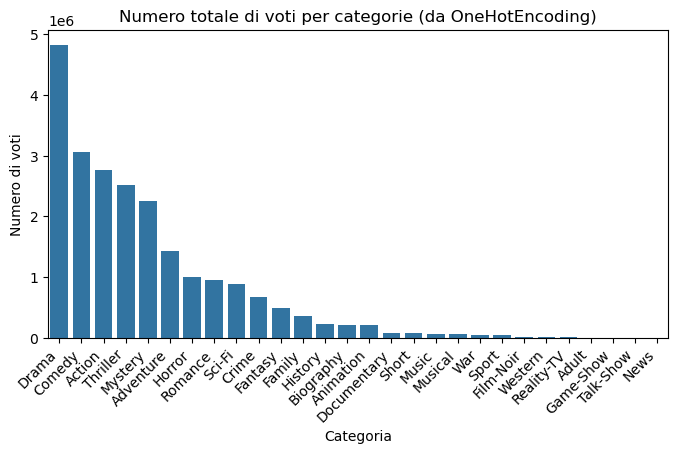

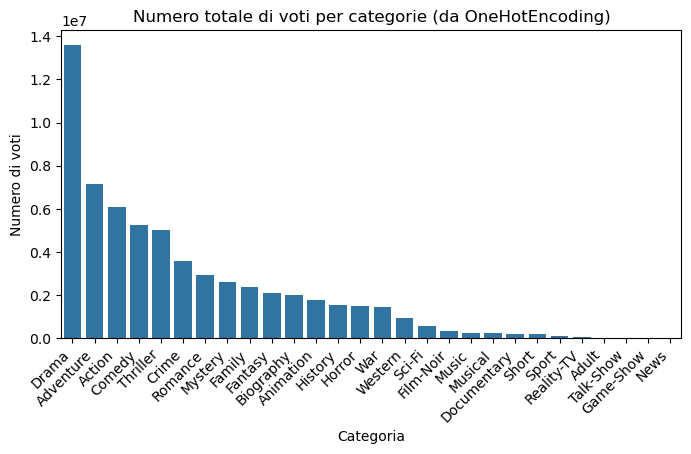

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_votes_by_genre(data, genre_column, vote_column):
    """Generate a bar plot for total votes by genre."""
    data_genres = data.assign(genres=data[genre_column].str.split(',')).explode(genre_column)
    votes_by_genre = data_genres.groupby(genre_column)[vote_column].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=votes_by_genre.index, y=votes_by_genre.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Numero totale di voti per genere')
    plt.xlabel('Genere')
    plt.ylabel('Numero di voti')
    plt.show()

def plot_from_onehot_file(data, file_path, vote_column):
    """Generate a bar plot using columns specified in a .txt file with one-hot encoding columns."""
    # Read the columns of interest from the file
    with open(file_path, 'r') as f:
        onehot_columns = [line.strip() for line in f.readlines()]

    # Filter out missing columns
    available_columns = [col for col in onehot_columns if col in data.columns]
    missing_columns = [col for col in onehot_columns if col not in data.columns]

    if missing_columns:
        print(f"Warning: The following columns are missing and will be ignored: {missing_columns}")

    # Aggregate votes for each available column
    votes_by_column = data[available_columns].multiply(data[vote_column], axis=0).sum().sort_values(ascending=False)

    # Create the bar plot
    plt.figure(figsize=(8, 4))
    sns.barplot(x=votes_by_column.index, y=votes_by_column.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Numero totale di voti per categorie (da OneHotEncoding)')
    plt.xlabel('Categoria')
    plt.ylabel('Numero di voti')
    plt.show()


plot_from_onehot_file(data_train, 'encoding_lists/genres.txt', 'numVotes')
plot_from_onehot_file(data_test, 'encoding_lists/genres.txt', 'numVotes')

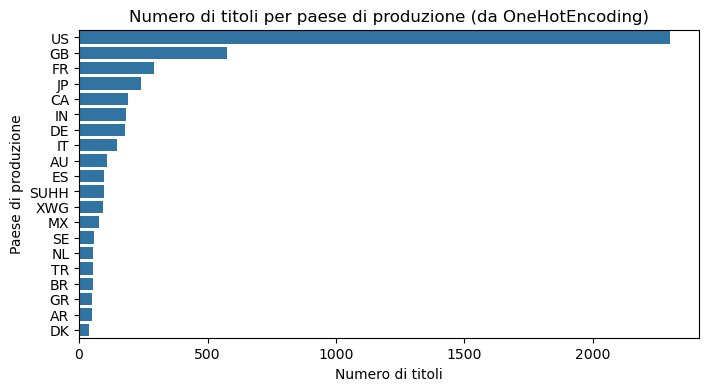

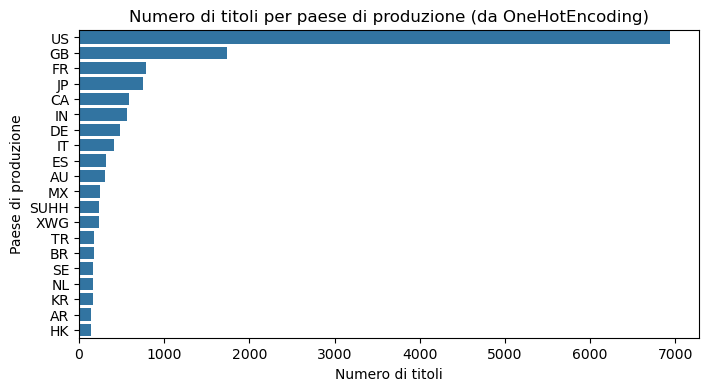

In [13]:

def plot_titles_by_country(data, country_column):
    """Generate a bar plot for the number of titles by country."""
    data_countries = data.assign(countryOfOrigin=data[country_column].str.strip("[]").str.replace("'", "").str.split(',')).explode(country_column)
    data_countries[country_column] = data_countries[country_column].str.strip()

    titles_by_country = data_countries[country_column].value_counts().head(20)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=titles_by_country.values, y=titles_by_country.index)
    plt.title('Numero di titoli per paese di produzione')
    plt.xlabel('Numero di titoli')
    plt.ylabel('Paese di produzione')
    plt.show()


def plot_titles_from_onehot_file(data, file_path):
    """Generate a bar plot using columns specified in a .txt file with one-hot encoding columns for countries."""
    # Read the columns of interest from the file
    with open(file_path, 'r') as f:
        onehot_columns = [line.strip() for line in f.readlines()]

    # Filter out missing columns
    available_columns = [col for col in onehot_columns if col in data.columns]
    missing_columns = [col for col in onehot_columns if col not in data.columns]

    if missing_columns:
        print(f"Warning: The following columns are missing and will be ignored: {missing_columns}")

    # Count titles for each available column
    titles_by_column = data[available_columns].sum().sort_values(ascending=False).head(20)

    # Create the bar plot
    plt.figure(figsize=(8, 4))
    sns.barplot(x=titles_by_column.values, y=titles_by_column.index)
    plt.title('Numero di titoli per paese di produzione (da OneHotEncoding)')
    plt.xlabel('Numero di titoli')
    plt.ylabel('Paese di produzione')
    plt.show()


plot_titles_from_onehot_file(data_train, 'encoding_lists/countryOfOrigin.txt')
plot_titles_from_onehot_file(data_test, 'encoding_lists/countryOfOrigin.txt')

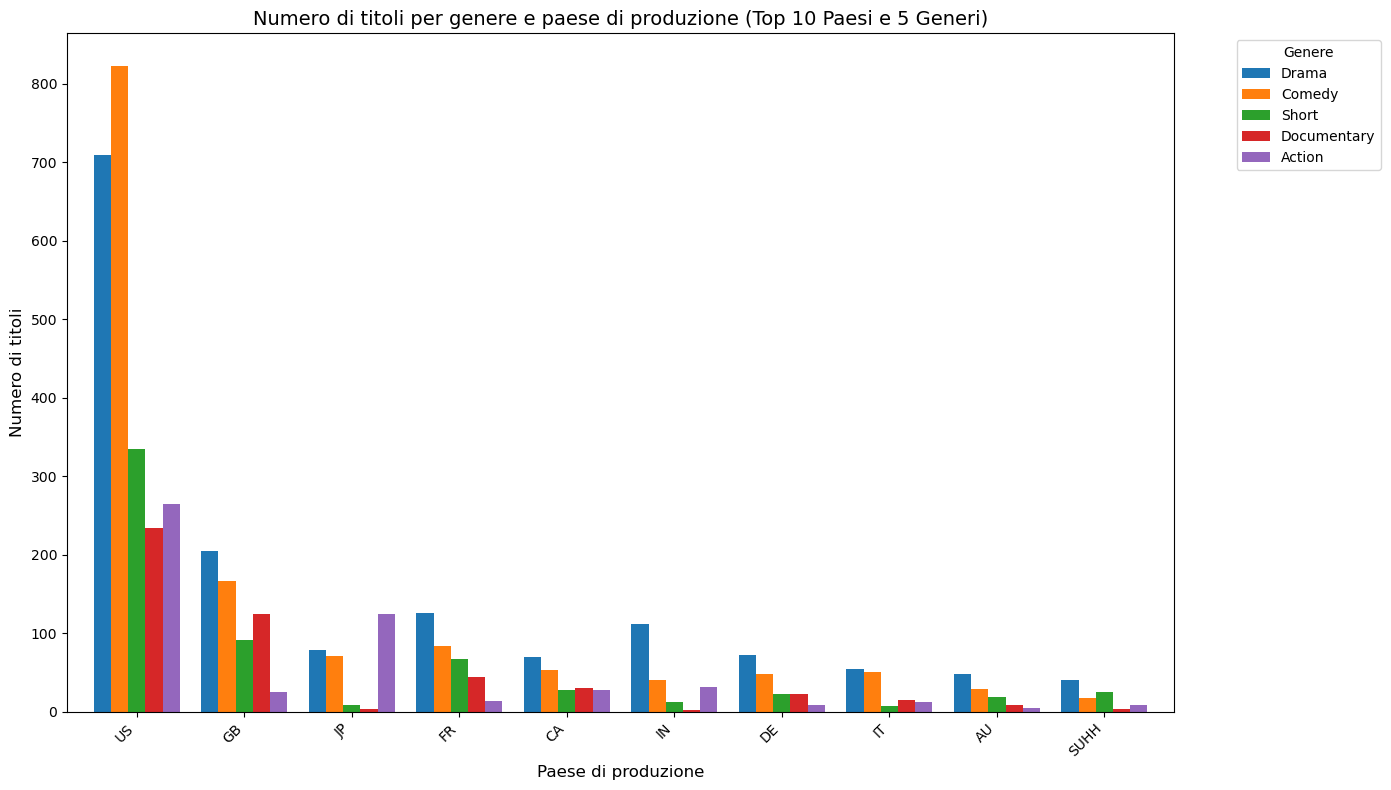

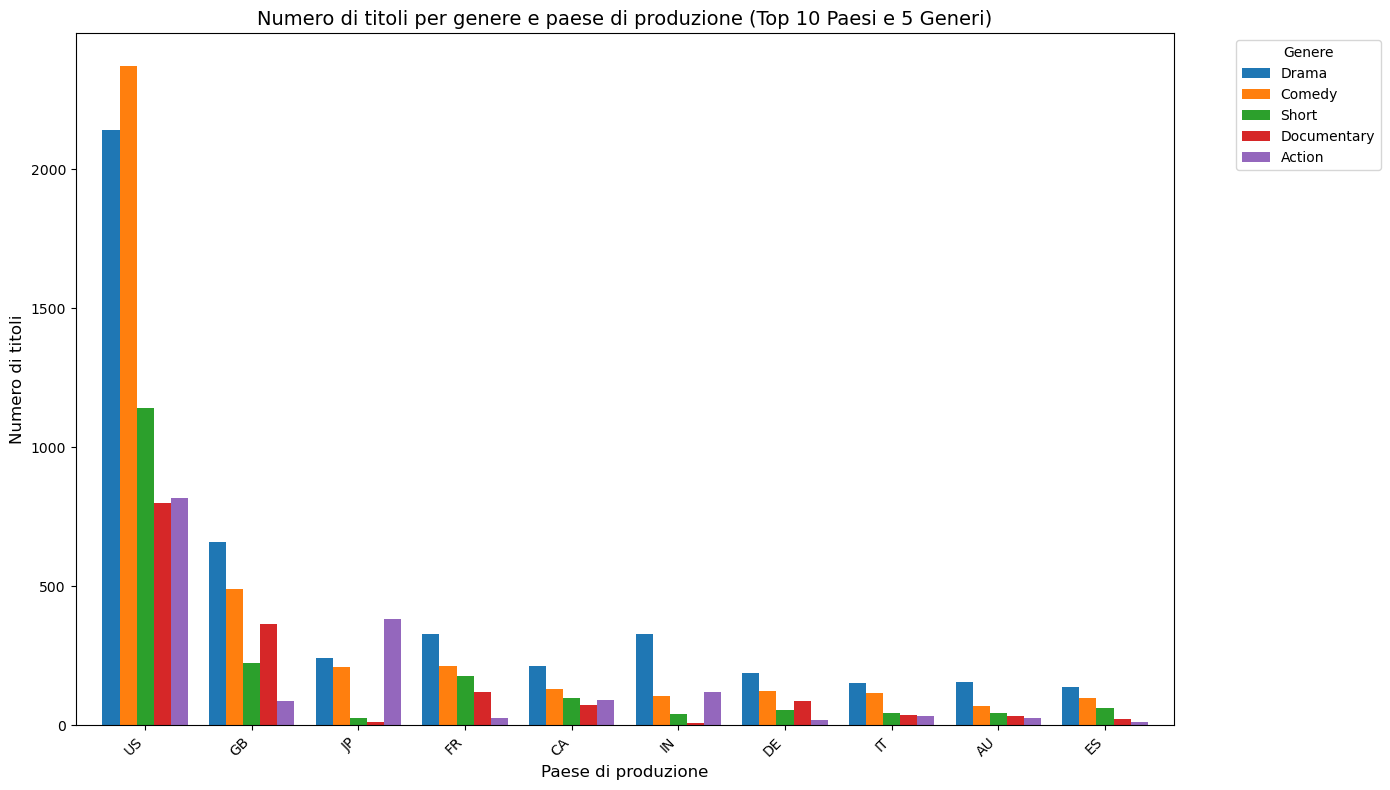

In [14]:

def plot_titles_by_genre_and_country(data, genre_column, country_column, top_countries=10, top_genres=5):
    """Generate a grouped bar plot for the number of titles by genre and country."""
    data_cleaned = data.assign(
        genres=data[genre_column].str.strip("[]").str.replace("'", "").str.split(','),
        countryOfOrigin=data[country_column].str.strip("[]").str.replace("'", "").str.split(',')
    )
    data_genres_countries = data_cleaned.explode('genres').explode('countryOfOrigin')
    data_genres_countries['genres'] = data_genres_countries['genres'].str.strip()
    data_genres_countries['countryOfOrigin'] = data_genres_countries['countryOfOrigin'].str.strip()
    data_genres_countries = data_genres_countries.dropna(subset=['genres', 'countryOfOrigin'])

    genre_country_counts = data_genres_countries.groupby(['countryOfOrigin', 'genres']).size().reset_index(name='count')

    pivot = genre_country_counts.pivot(index='countryOfOrigin', columns='genres', values='count').fillna(0)

    top_countries_list = genre_country_counts['countryOfOrigin'].value_counts().head(top_countries).index
    top_genres_list = genre_country_counts['genres'].value_counts().head(top_genres).index

    filtered_data = genre_country_counts[
        (genre_country_counts['countryOfOrigin'].isin(top_countries_list)) &
        (genre_country_counts['genres'].isin(top_genres_list))
    ]

    pivot_grouped = filtered_data.pivot(index='countryOfOrigin', columns='genres', values='count').fillna(0)

    pivot_grouped.plot(kind='bar', figsize=(14, 8), width=0.8)
    plt.title('Numero di titoli per genere e paese di produzione (Top 10 Paesi e 5 Generi)', fontsize=14)
    plt.xlabel('Paese di produzione', fontsize=12)
    plt.ylabel('Numero di titoli', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.legend(title='Genere', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_titles_by_genre_and_country(data, genre_file, country_file, top_countries=10, top_genres=5):
    """Generate a grouped bar plot for the number of titles by genre and country using double one-hot encoding."""
    # Read the one-hot encoding columns from the files
    with open(genre_file, 'r') as f:
        genre_columns = [line.strip() for line in f.readlines()]

    with open(country_file, 'r') as f:
        country_columns = [line.strip() for line in f.readlines()]

    # Filter out missing columns
    available_genre_columns = [col for col in genre_columns if col in data.columns]
    missing_genre_columns = [col for col in genre_columns if col not in data.columns]

    available_country_columns = [col for col in country_columns if col in data.columns]
    missing_country_columns = [col for col in country_columns if col not in data.columns]

    if missing_genre_columns:
        print(f"Warning: The following genre columns are missing and will be ignored: {missing_genre_columns}")

    if missing_country_columns:
        print(f"Warning: The following country columns are missing and will be ignored: {missing_country_columns}")

    # Create a DataFrame for the counts of genre-country combinations
    genre_country_counts = pd.DataFrame()

    for country in available_country_columns:
        for genre in available_genre_columns:
            genre_country_counts.loc[country, genre] = (data[country] * data[genre]).sum()

    # Filter for top countries and genres
    top_countries_list = genre_country_counts.sum(axis=1).nlargest(top_countries).index
    top_genres_list = genre_country_counts.sum(axis=0).nlargest(top_genres).index

    filtered_counts = genre_country_counts.loc[top_countries_list, top_genres_list]

    # Plot the grouped bar plot
    filtered_counts.plot(kind='bar', figsize=(14, 8), width=0.8)
    plt.title('Numero di titoli per genere e paese di produzione (Top 10 Paesi e 5 Generi)', fontsize=14)
    plt.xlabel('Paese di produzione', fontsize=12)
    plt.ylabel('Numero di titoli', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.legend(title='Genere', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_titles_by_genre_and_country(data_train, 'encoding_lists/genres.txt', 'encoding_lists/countryOfOrigin.txt')
plot_titles_by_genre_and_country(data_test, 'encoding_lists/genres.txt', 'encoding_lists/countryOfOrigin.txt')

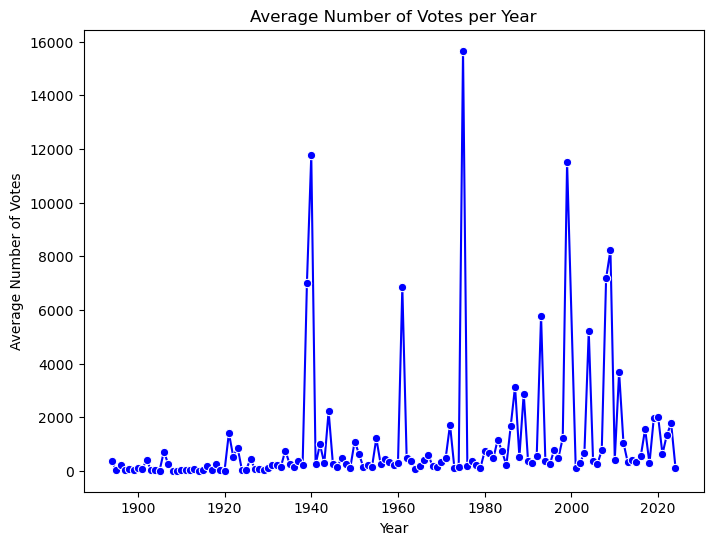

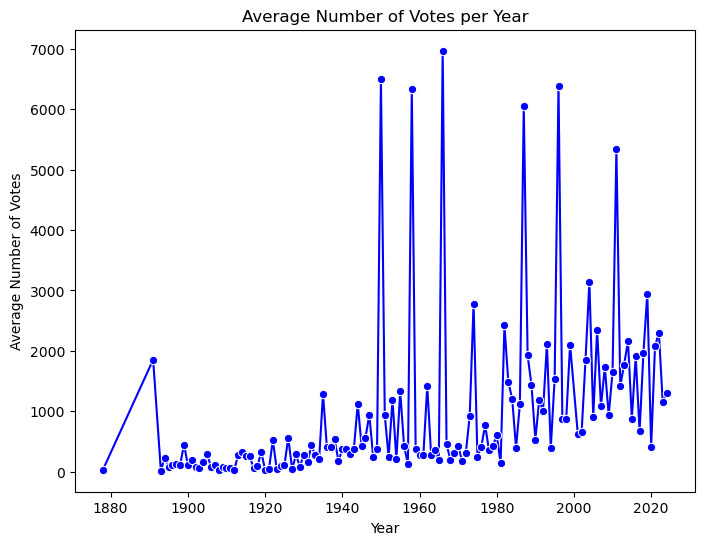

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_line_average(data, group_by_column, value_column, title, xlabel, ylabel, marker='o', color='blue'):
    """
    Crea un lineplot che mostra la media dei valori di una colonna raggruppati per un'altra colonna.
    """
    avg_values = data.groupby(group_by_column)[value_column].mean().reset_index()
    plt.figure(figsize=(8, 6))
    sns.lineplot(x=group_by_column, y=value_column, data=avg_values, marker=marker, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

plot_line_average(data_train, 'startYear', 'numVotes', 'Average Number of Votes per Year', 'Year', 'Average Number of Votes')
plot_line_average(data_test, 'startYear', 'numVotes', 'Average Number of Votes per Year', 'Year', 'Average Number of Votes')

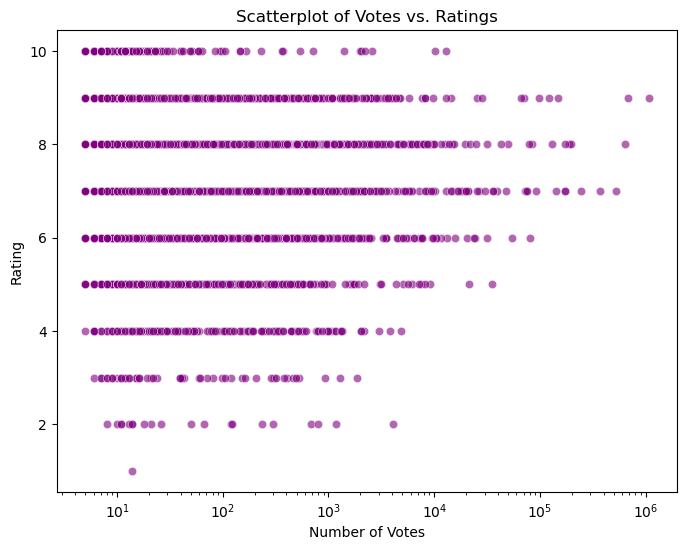

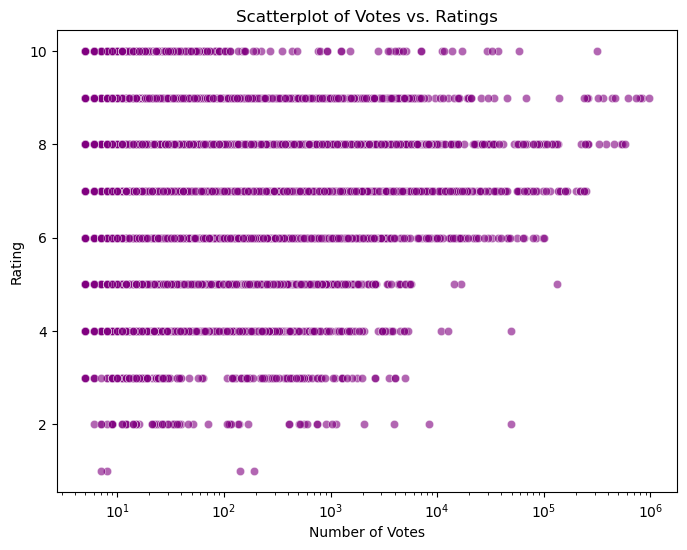

In [16]:

def plot_scatter(data, x_column, y_column, title, xlabel, ylabel, alpha=0.6, color='purple', log_scale_x=False):
    """
    Crea uno scatterplot tra due colonne specificate.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=x_column, y=y_column, data=data, alpha=alpha, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if log_scale_x:
        plt.xscale('log')  # Scala logaritmica per l'asse x se richiesto
    plt.show()

plot_scatter(data_train, 'numVotes', 'rating', 'Scatterplot of Votes vs. Ratings', 'Number of Votes', 'Rating', log_scale_x=True)
plot_scatter(data_test, 'numVotes', 'rating', 'Scatterplot of Votes vs. Ratings', 'Number of Votes', 'Rating', log_scale_x=True)


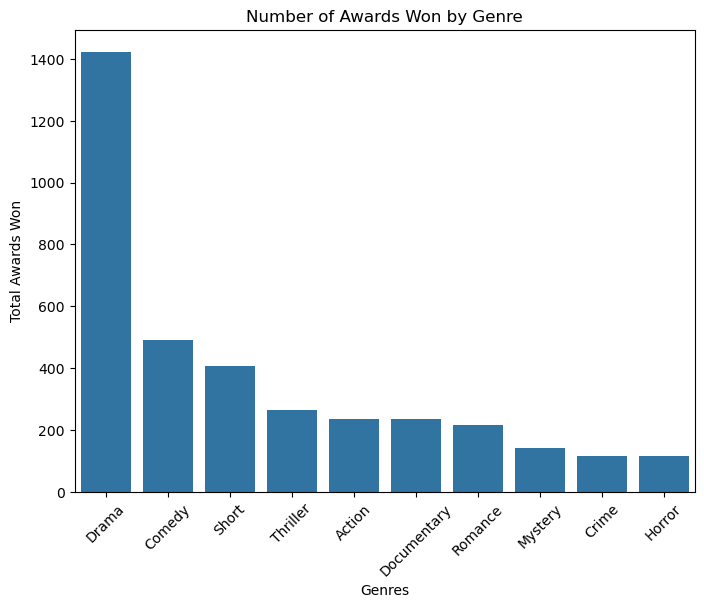

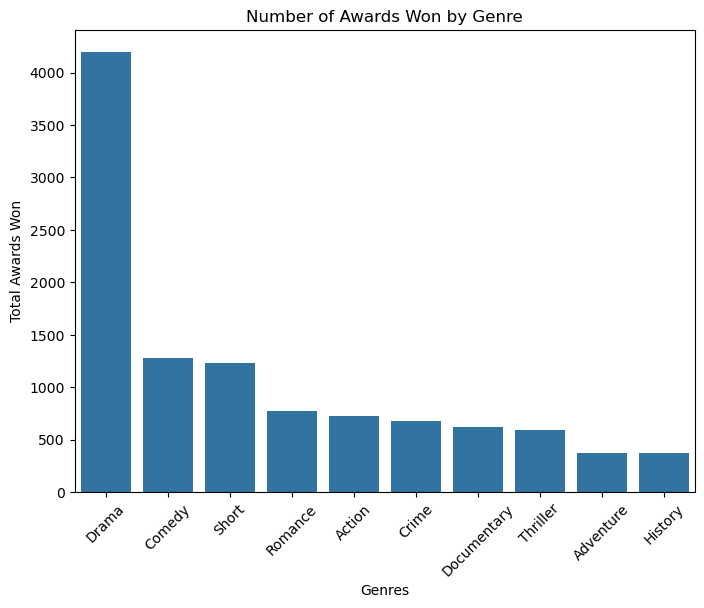

In [17]:

def plot_bar_grouped_sum(data, group_by_column, value_column, title, xlabel, ylabel, top_n=10):
    """
    Crea un barplot che mostra la somma dei valori di una colonna raggruppati per un'altra colonna.
    """
    grouped_data = data.assign(group=data[group_by_column].str.split(',')).explode('group')
    grouped_sum = grouped_data.groupby('group')[value_column].sum().sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=grouped_sum.index, y=grouped_sum.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bar_grouped_sum_onehot(data, onehot_file, value_column, title, xlabel, ylabel, top_n=10):
    """
    Crea un barplot che mostra la somma dei valori di una colonna basata su colonne one-hot encoding.
    
    Args:
        data (pd.DataFrame): Il DataFrame contenente i dati.
        onehot_file (str): Percorso del file .txt con i nomi delle colonne one-hot encoding.
        value_column (str): La colonna dei valori da sommare.
        title (str): Titolo del grafico.
        xlabel (str): Etichetta dell'asse x.
        ylabel (str): Etichetta dell'asse y.
        top_n (int): Numero massimo di categorie da mostrare.
    """
    # Leggere le colonne one-hot dal file
    with open(onehot_file, 'r') as f:
        onehot_columns = [line.strip() for line in f.readlines()]

    # Filtrare le colonne disponibili nel DataFrame
    available_columns = [col for col in onehot_columns if col in data.columns]
    missing_columns = [col for col in onehot_columns if col not in data.columns]

    if missing_columns:
        print(f"Warning: The following columns are missing and will be ignored: {missing_columns}")

    # Calcolare la somma per ciascuna colonna disponibile
    grouped_sum = data[available_columns].multiply(data[value_column], axis=0).sum().sort_values(ascending=False).head(top_n)

    # Creare il grafico
    plt.figure(figsize=(8, 6))
    sns.barplot(x=grouped_sum.index, y=grouped_sum.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.show()

# Esempio di chiamata
plot_bar_grouped_sum_onehot(data_train, 'encoding_lists/genres.txt', 'awardWins', 'Number of Awards Won by Genre', 'Genres', 'Total Awards Won')
plot_bar_grouped_sum_onehot(data_test, 'encoding_lists/genres.txt', 'awardWins', 'Number of Awards Won by Genre', 'Genres', 'Total Awards Won')


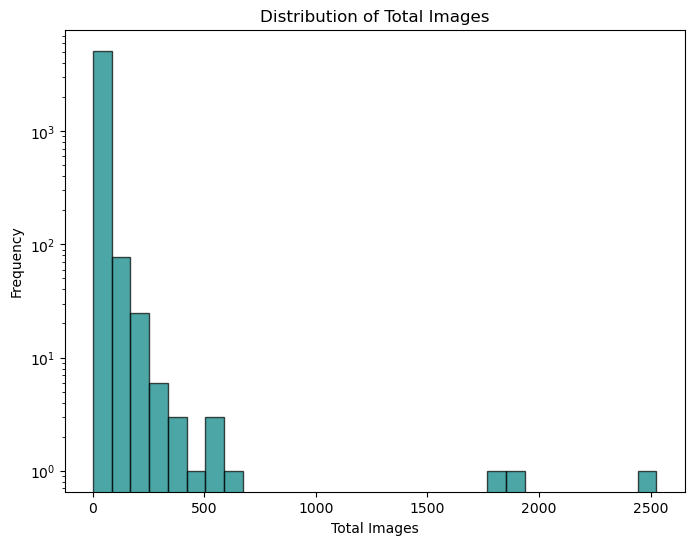

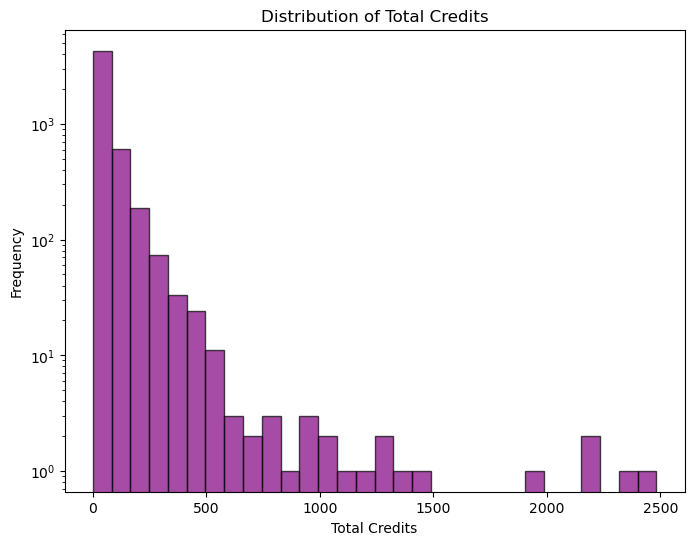

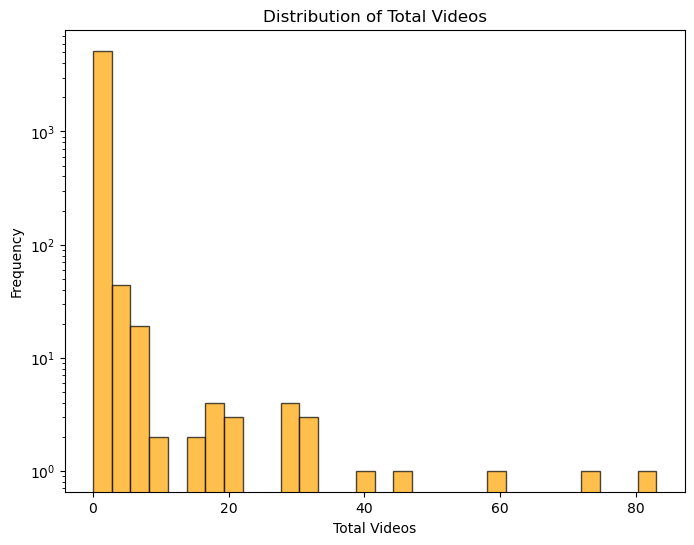

In [18]:
# Histogram: Distribution of Total Images, Total Credits, Total Videos
plt.figure(figsize=(8, 6))
plt.hist(data_train['totalImages'], bins=30, color='teal', alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Images')
plt.xlabel('Total Images')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale to better visualize the skewed distribution
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(data_train['totalCredits'], bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Credits')
plt.xlabel('Total Credits')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale to better visualize the skewed distribution
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(data_train['totalVideos'], bins=30, color='orange', alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Videos')
plt.xlabel('Total Videos')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale to better visualize the skewed distribution
plt.show()


/tmp/ipykernel_6345/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_6345/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_6345/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_6345/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

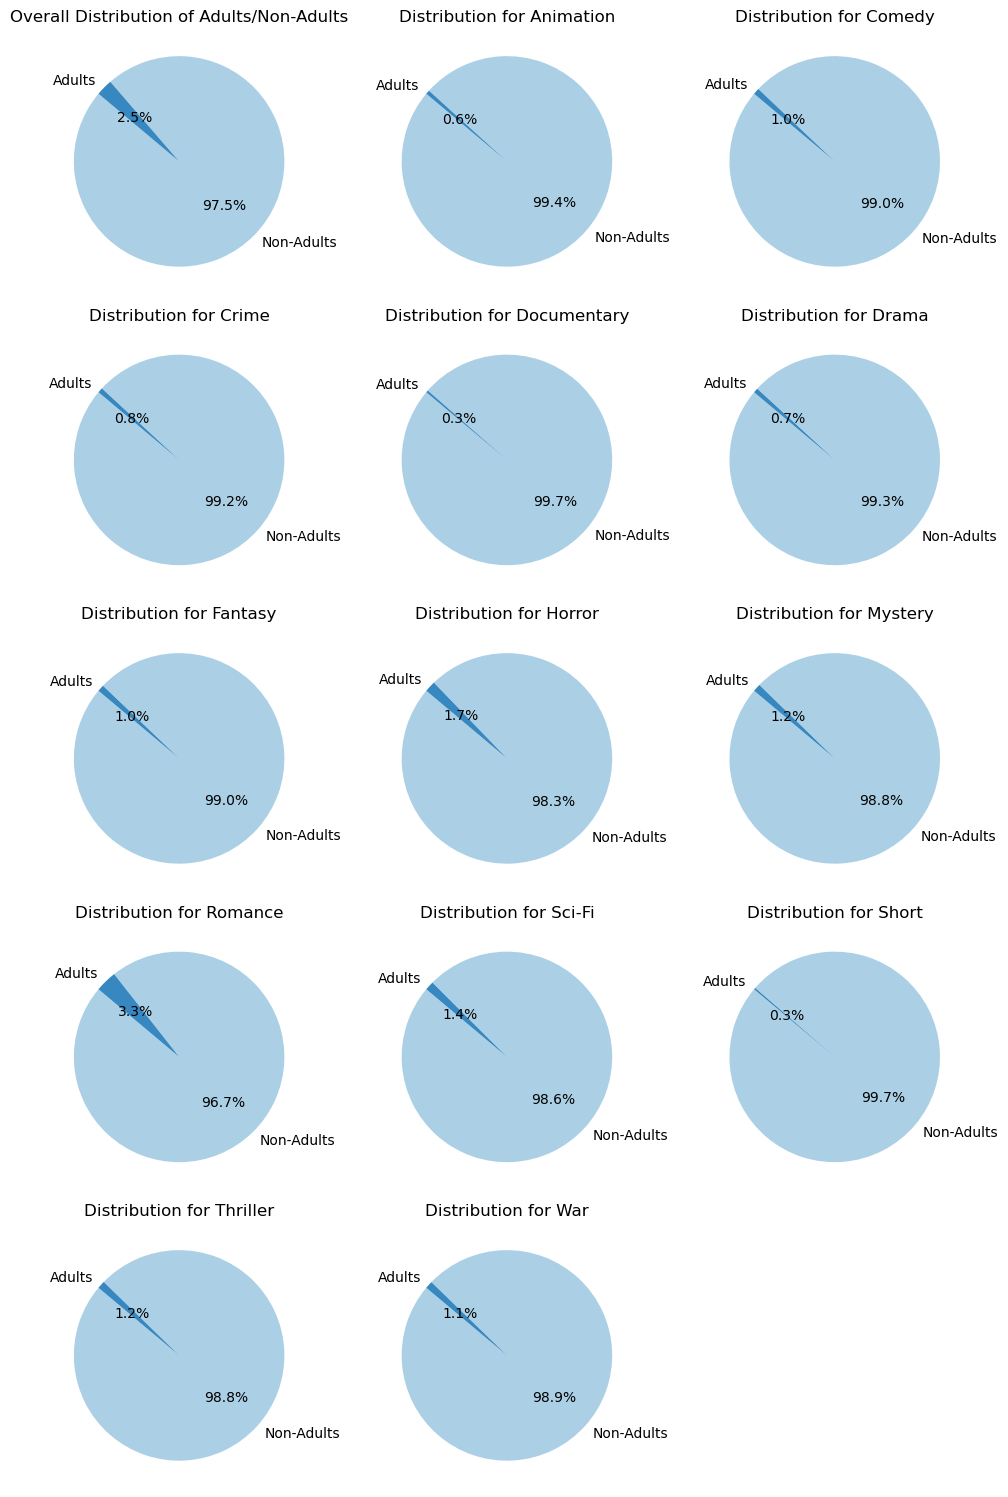

Genres without adult products: ['Action', 'Adult', 'Adventure', 'Biography', 'Family', 'Film-Noir', 'Game-Show', 'History', 'Music', 'Musical', 'News', 'Reality-TV', 'Sport', 'Talk-Show', 'Western']


/tmp/ipykernel_6345/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_6345/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_6345/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_6345/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

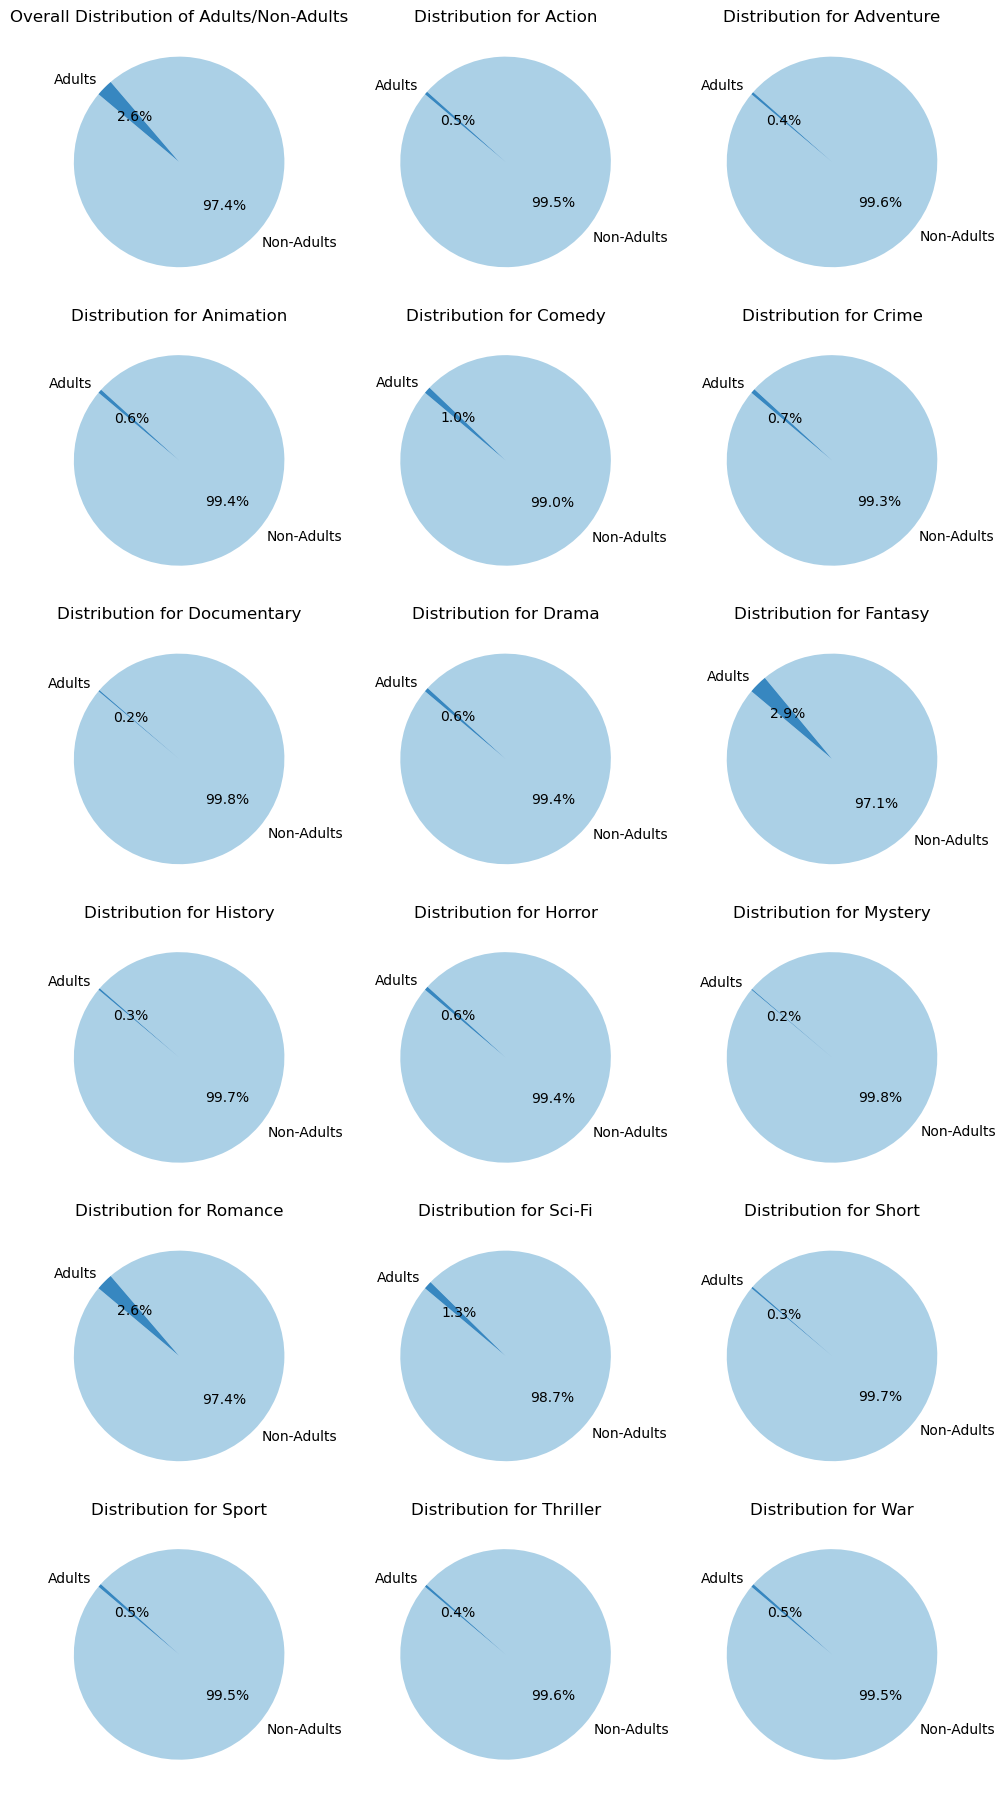

Genres without adult products: ['Adult', 'Biography', 'Family', 'Film-Noir', 'Game-Show', 'Music', 'Musical', 'News', 'Reality-TV', 'Talk-Show', 'Western']


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_isAdult_distribution(data, onehot_file):
    """
    Crea un'unica immagine con grafici a torta per la distribuzione di isAdult complessiva e per ogni genere.
    Utilizza il colorscheme "Blues".

    Args:
        data (pd.DataFrame): Il DataFrame contenente i dati.
        onehot_file (str): Percorso del file .txt con i nomi delle colonne one-hot encoding.
    """
    # Leggere le colonne one-hot dal file
    with open(onehot_file, 'r') as f:
        onehot_columns = [line.strip() for line in f.readlines()]

    # Filtrare le colonne disponibili nel DataFrame
    available_columns = [col for col in onehot_columns if col in data.columns]
    missing_columns = [col for col in onehot_columns if col not in data.columns]

    if missing_columns:
        print(f"Warning: The following columns are missing and will be ignored: {missing_columns}")

    # Lista dei generi senza prodotti per adulti
    no_adult_genres = []

    # Determinare il numero totale di grafici
    num_plots = len(available_columns) + 1  # Include il grafico generale
    cols = 3  # Numero di colonne nel layout
    rows = (num_plots // cols) + (num_plots % cols > 0)  # Calcolo delle righe necessarie

    # Creare il layout della figura
    fig, axes = plt.subplots(rows, cols, figsize=(10, rows * 3))
    axes = axes.flatten()

    # Grafico generale per isAdult
    general_ax = axes[0]
    data['isAdult'].value_counts().plot.pie(
        autopct='%1.1f%%', labels=['Non-Adults', 'Adults'], colors=sns.color_palette("Blues", 2), startangle=140, ax=general_ax
    )
    general_ax.set_title('Overall Distribution of Adults/Non-Adults')
    general_ax.set_ylabel('')

    plot_index = 1  # Indice per i grafici validi

    # Grafici per ogni genere
    for genre in available_columns:
        genre_data = data[data[genre] == 1]  # Filtra per il genere corrente
        if not genre_data.empty:
            counts = genre_data['isAdult'].value_counts(normalize=True)
            if counts.get(1, 0) == 0:  # Controlla se non ci sono prodotti per adulti
                no_adult_genres.append(genre)
                continue

            genre_ax = axes[plot_index]
            genre_data['isAdult'].value_counts().plot.pie(
                autopct='%1.1f%%', labels=['Non-Adults', 'Adults'], colors=sns.color_palette("Blues", 2), startangle=140, ax=genre_ax
            )
            genre_ax.set_title(f'Distribution for {genre}')
            genre_ax.set_ylabel('')
            plot_index += 1

    # Rimuovere assi vuoti
    for j in range(plot_index, len(axes)):
        fig.delaxes(axes[j])

    # Layout finale
    plt.tight_layout()
    plt.show()

    # Stampa dei generi senza prodotti per adulti
    if no_adult_genres:
        print(f"Genres without adult products: {no_adult_genres}")



# Esempio di chiamata
plot_isAdult_distribution(data_train, 'encoding_lists/genres.txt')
plot_isAdult_distribution(data_test, 'encoding_lists/genres.txt')

# analisi grafico 2
Analisi del grafico
Distribuzione uniforme per rating:

I valori di rating sembrano distribuiti in modo simile per la maggior parte dei generi. Non ci sono generi con valori estremi (molto alti o bassi).
Differenze marcate in numVotes:

Il numero di voti (numVotes) è un discriminante significativo. Alcuni generi, come "Drama" e "Action", tendono ad avere un numero di voti molto alto, mentre generi come "Short", "Family", e "Crime" ne hanno relativamente pochi.
awardWins più bassi per alcuni generi:

Generi come "Drama" e "Documentary" mostrano un maggiore numero di premi vinti, rispetto a generi come "Family" o "Short", che generalmente ottengono meno riconoscimenti.
Picchi per alcuni generi specifici:

"Drama" e "Documentary" si distinguono come generi con un buon bilanciamento tra i tre parametri (rating, numVotes, awardWins).
"Short" e "Family" tendono a essere poco rappresentati in termini di numVotes e awardWins.

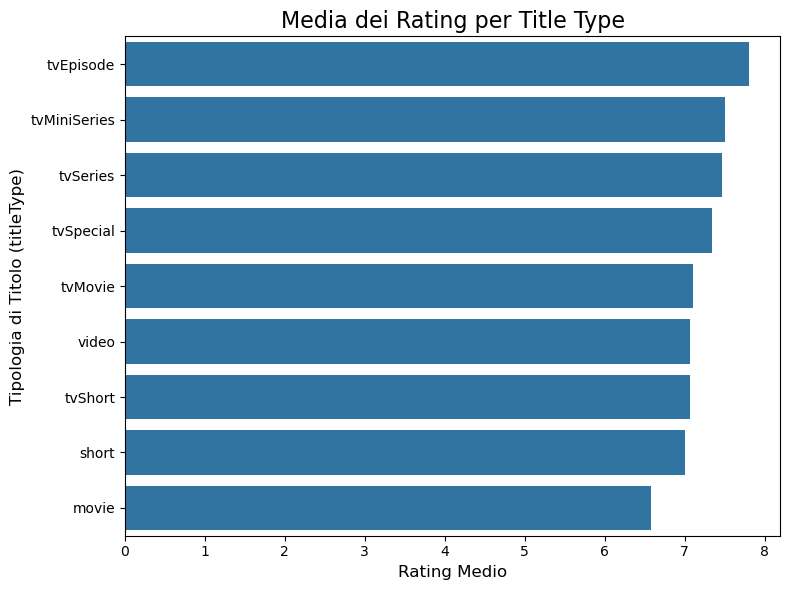

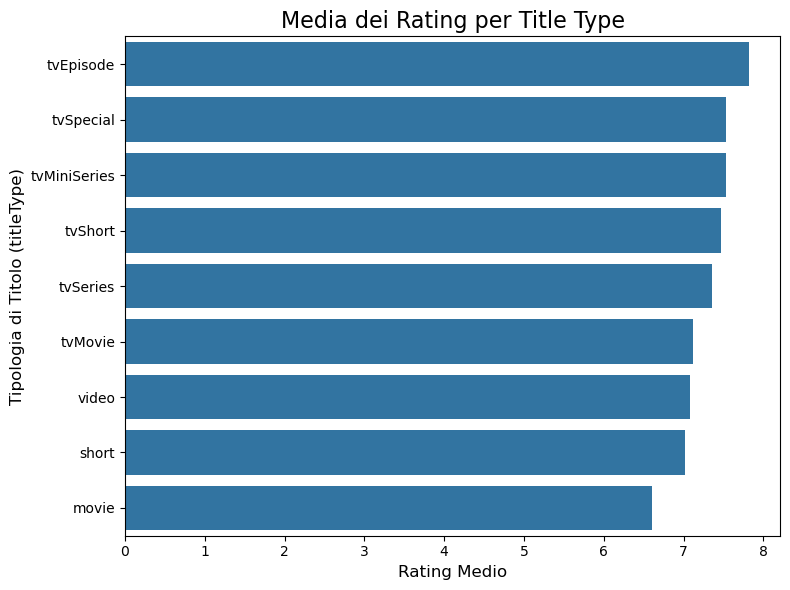

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_average_rating_by_title_type(data):
    """
    Crea un barplot che mostra la media dei rating per ogni tipo di titolo (titleType).

    Args:
        data (pd.DataFrame): Il DataFrame contenente i dati con le colonne 'titleType' e 'rating'.
    """
    # Calcoliamo la media dei rating per ogni tipo di titolo
    rating_by_type = data.groupby('titleType')['rating'].mean().sort_values(ascending=False).reset_index()

    # Creazione del barplot
    plt.figure(figsize=(8, 6))
    sns.barplot(x='rating', y='titleType', data=rating_by_type)

    plt.title('Media dei Rating per Title Type', fontsize=16)
    plt.xlabel('Rating Medio', fontsize=12)
    plt.ylabel('Tipologia di Titolo (titleType)', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_average_rating_by_title_type(data_train)
plot_average_rating_by_title_type(data_test)


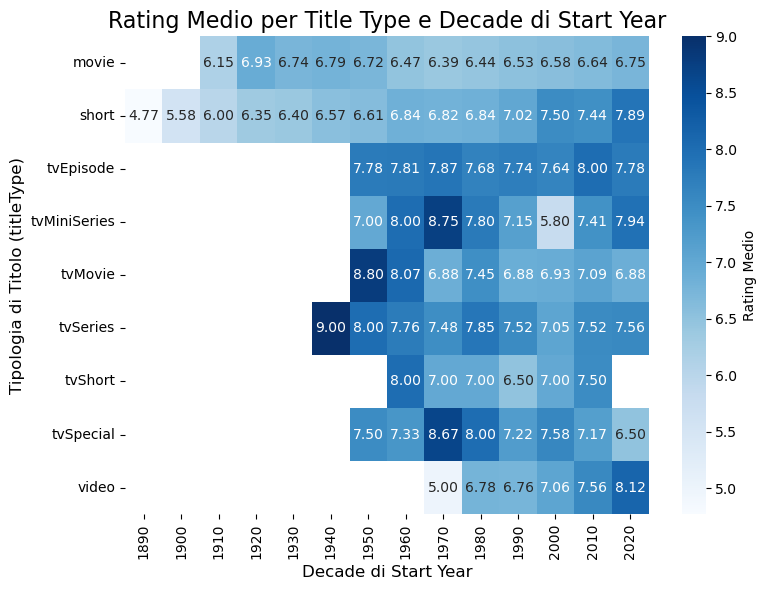

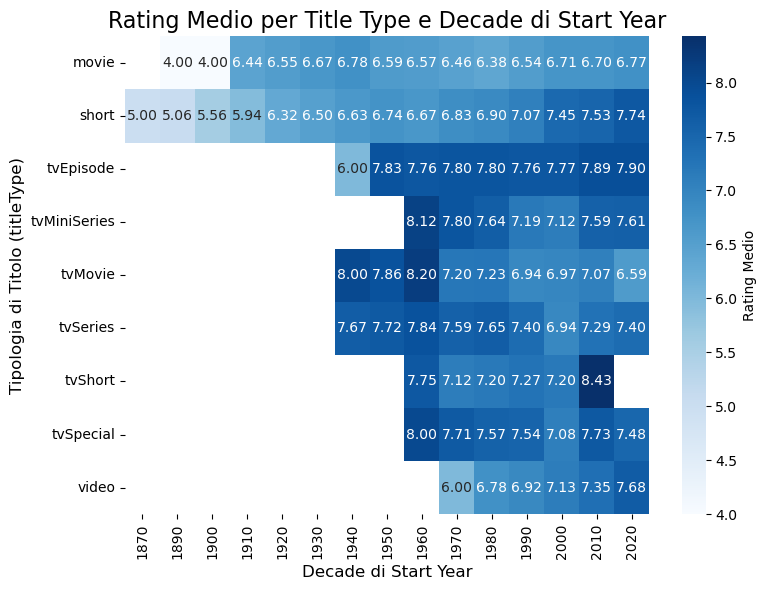

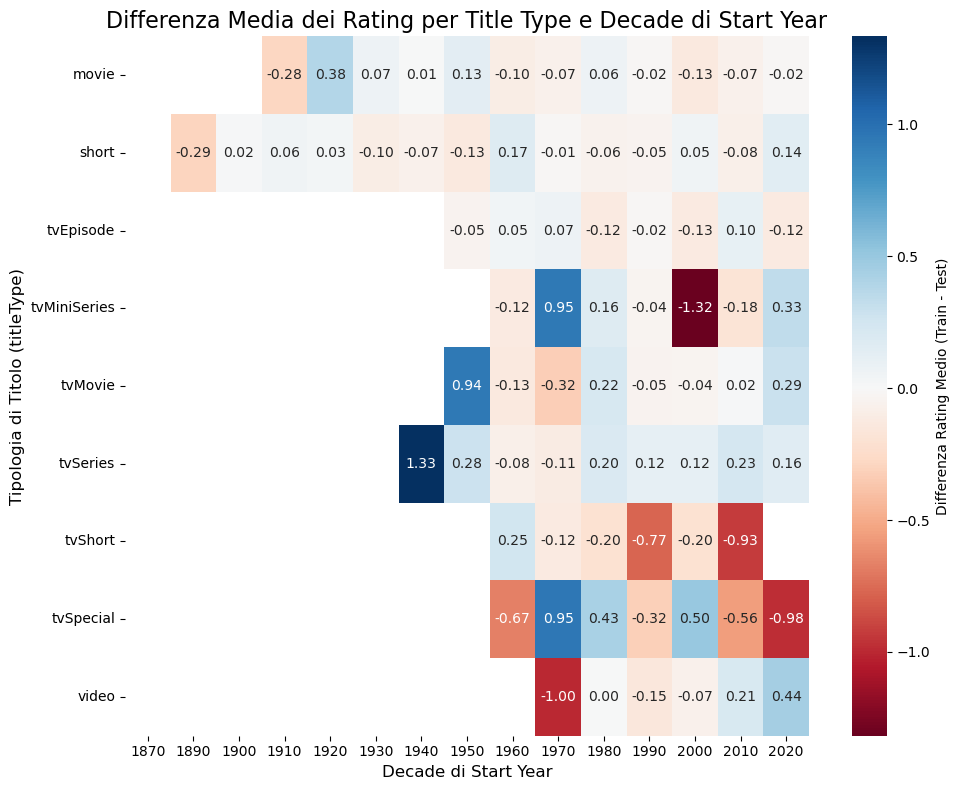

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap_rating_by_title_type_and_decade(data):
    """
    Crea una heatmap che mostra il rating medio per combinazioni di titleType e decade di startYear.

    Args:
        data (pd.DataFrame): Il DataFrame contenente i dati con le colonne 'titleType', 'startYear', e 'rating'.
    """
    # Creiamo una colonna per categorizzare 'startYear' in intervalli (decadi)
    data['startYearDecade'] = (data['startYear'] // 10) * 10

    # Calcoliamo la media dei rating per combinazioni di titleType e decade
    heatmap_data = data.groupby(['titleType', 'startYearDecade'])['rating'].mean().unstack()

    # Creazione della heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar_kws={'label': 'Rating Medio'}
    )

    plt.title('Rating Medio per Title Type e Decade di Start Year', fontsize=16)
    plt.xlabel('Decade di Start Year', fontsize=12)
    plt.ylabel('Tipologia di Titolo (titleType)', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_comparison_heatmap(data_train, data_test):
    """
    Crea una heatmap che confronta i rating medi tra data_train e data_test per titleType e startYear decade.

    Args:
        data_train (pd.DataFrame): Il dataset di training.
        data_test (pd.DataFrame): Il dataset di test.
    """
    # Creiamo una colonna per categorizzare 'startYear' in intervalli (decadi)
    data_train['startYearDecade'] = (data_train['startYear'] // 10) * 10
    data_test['startYearDecade'] = (data_test['startYear'] // 10) * 10

    # Calcoliamo la media dei rating per combinazioni di titleType e decade
    train_heatmap_data = data_train.groupby(['titleType', 'startYearDecade'])['rating'].mean().unstack()
    test_heatmap_data = data_test.groupby(['titleType', 'startYearDecade'])['rating'].mean().unstack()

    # Sottraiamo i dati di test da quelli di training
    comparison_data = train_heatmap_data - test_heatmap_data

    # Creazione della heatmap con scala colori personalizzata
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        comparison_data,
        annot=True,
        fmt=".2f",
        cmap="RdBu",
        center=0,
        cbar_kws={'label': 'Differenza Rating Medio (Train - Test)'}
    )

    plt.title('Differenza Media dei Rating per Title Type e Decade di Start Year', fontsize=16)
    plt.xlabel('Decade di Start Year', fontsize=12)
    plt.ylabel('Tipologia di Titolo (titleType)', fontsize=12)
    plt.tight_layout()
    plt.show()

# Esempi di chiamata
plot_heatmap_rating_by_title_type_and_decade(data_train)
plot_heatmap_rating_by_title_type_and_decade(data_test)
plot_comparison_heatmap(data_train, data_test)


In [22]:
def store_dataset(data, filename):
    
    file_path = f"{filename}.csv"
    data.to_csv(file_path, index=False)
    
    print(f"Dataset successfully stored as {file_path}")
    return file_path

test = store_dataset(data_test, 'data/output/01_data_understanding/data_train')
train = store_dataset(data_train, 'data/output/01_data_understanding/data_test')

Dataset successfully stored as data/output/01_data_understanding/data_train.csv
Dataset successfully stored as data/output/01_data_understanding/data_test.csv
